## 2-Qubit Circuit with 90° Phase Shift and Q-Sphere Visualization

The steps are as follows:
1. A Hadamard gate is applied to the first qubit to create a superposition.
2. A Phase (P) gate with an angle of \(\pi/2\) (which corresponds to 90°) is then applied to the same qubit.

Circuit with 90° Phase Shift:


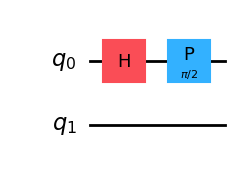


Q-sphere visualization:


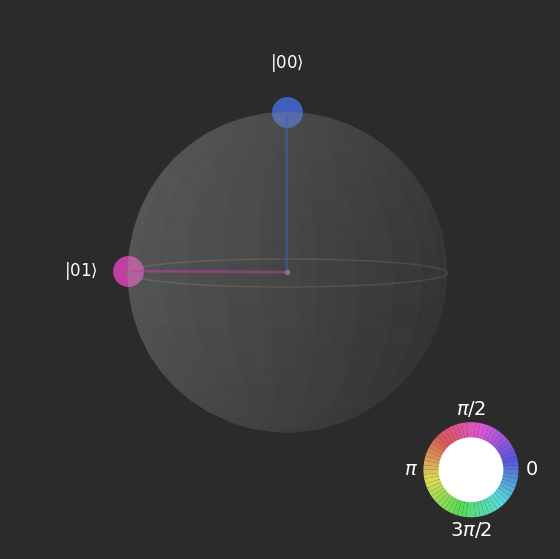

In [2]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_state_qsphere
import numpy as np

# Create a 2-qubit quantum circuit
qc = QuantumCircuit(2)

# 1. Apply a Hadamard gate to qubit 0 to create superposition
qc.h(0)

# 2. Apply a 90-degree (pi/2) phase shift to qubit 0
qc.p(np.pi/2, 0)

# Get the statevector of the final state
final_state = Statevector(qc)

# Print the circuit to see the gates
print("Circuit with 90° Phase Shift:")
display(qc.draw('mpl'))

# 3. Visualize the state using a Q-sphere
print("\nQ-sphere visualization:")
plot_state_qsphere(final_state)

## Importing and Running a Circuit from OpenQASM

1.  Define a simple Bell state circuit using the OpenQASM 2.0 syntax. named it with w4a
2.  Use Qiskit's `QuantumCircuit.from_qasm_file()` method to import the circuit from the file.
3.  Visualize the final state of the imported circuit to confirm it's the expected Bell state.


Imported Circuit:


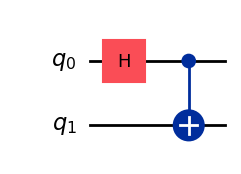


Q-sphere visualization of the imported circuit's state:


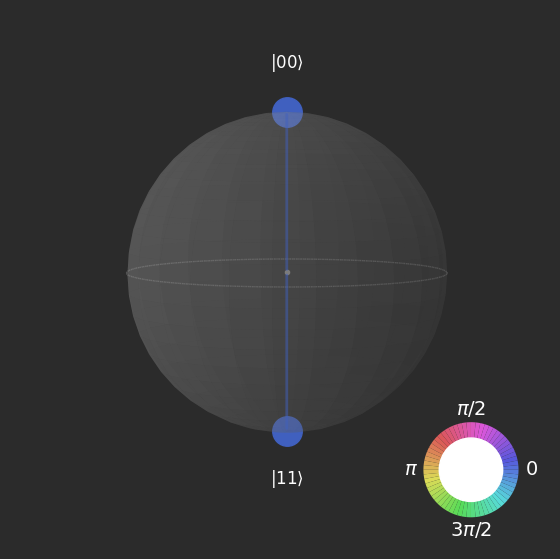

In [3]:

# 1. a file named 'w4a.qasm'
qasm_filename = "w4a.qasm"

# 2. Import the circuit from the QASM file
imported_qc = QuantumCircuit.from_qasm_file(qasm_filename)

print("\nImported Circuit:")
display(imported_qc.draw('mpl'))

# 3. Get the statevector and visualize it
final_state_from_qasm = Statevector(imported_qc)

print("\nQ-sphere visualization of the imported circuit's state:")
plot_state_qsphere(final_state_from_qasm)



## Density Matrix – Diagonal and Off-Diagonal Elements

The elements of the density matrix have clear physical interpretations:

*   **Diagonal Elements (\(\rho_{ii}\))**: These are called **populations**. Each diagonal element represents the classical probability of measuring the system in the corresponding basis state \(|i\rangle\). The sum of all diagonal elements must equal 1.

*   **Off-Diagonal Elements (\(\rho_{ij}\) for \(i \neq j\))**: These are called **coherences**. Non-zero off-diagonal elements are a definitive signature of quantum superposition and entanglement between the basis states \(|i\rangle\) and \(|j\rangle\). For a simple classical mixture of states, all off-diagonal elements are zero.

Circuit for creating a Bell State:


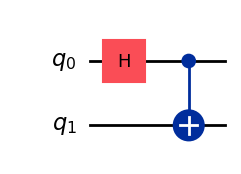


City plot of the Density Matrix:


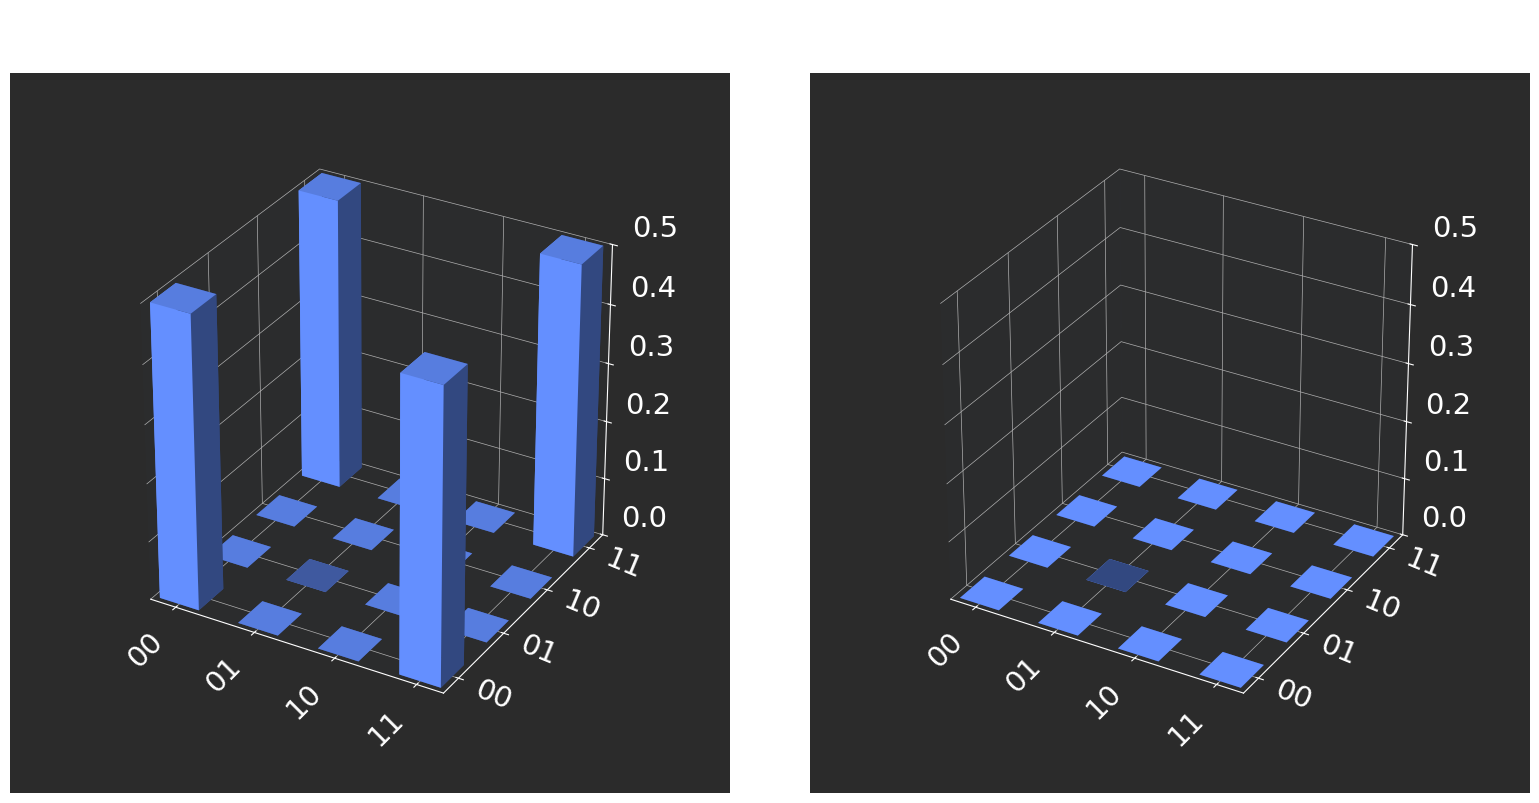


Latex representation of the Density Matrix:


<IPython.core.display.Latex object>

In [4]:
from qiskit.quantum_info import DensityMatrix
from qiskit.visualization import plot_state_city

# We will reuse the Bell state circuit from the previous section
bell_circuit = QuantumCircuit(2, name="Bell State")
bell_circuit.h(0)
bell_circuit.cx(0, 1)

# Create a DensityMatrix object from the circuit
density_matrix = DensityMatrix(bell_circuit)

# Print the circuit
print("Circuit for creating a Bell State:")
display(bell_circuit.draw('mpl'))

# Draw the density matrix using a city plot
# This visualization is great for seeing the magnitude of each matrix element
print("\nCity plot of the Density Matrix:")
display(plot_state_city(density_matrix, title="Density Matrix of a Bell State"))

# For a more direct view, we can also draw the matrix with its values
print("\nLatex representation of the Density Matrix:")
display(density_matrix.draw('latex'))


## Generating and Visualizing a Random Quantum Circuit

Qiskit provides a convenient function, `random_circuit`, to generate circuits with a random structure. This is incredibly useful for a variety of tasks, such as:


Random 2-qubit circuit with depth 3:


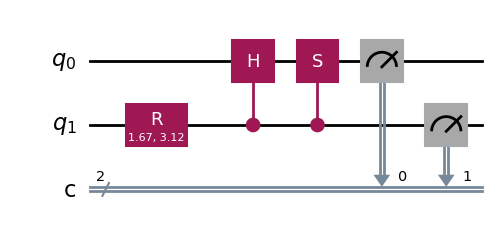

In [5]:
from qiskit.circuit.random import random_circuit

# Define the parameters for the random circuit
num_qubits = 2
depth = 3

# Generate a random circuit with measurements
# The `seed` parameter can be used for reproducibility if needed
random_qc = random_circuit(num_qubits, depth, measure=True)

# Print a header and visualize the circuit
print(f"Random {num_qubits}-qubit circuit with depth {depth}:")
display(random_qc.draw('mpl'))
